In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\ADYA TRIPATHI\Downloads\ML datsaets\insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.shape

(1338, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
# dropped the duplicate rows 
df = df[df.duplicated() != True]
df.shape

(1337, 7)

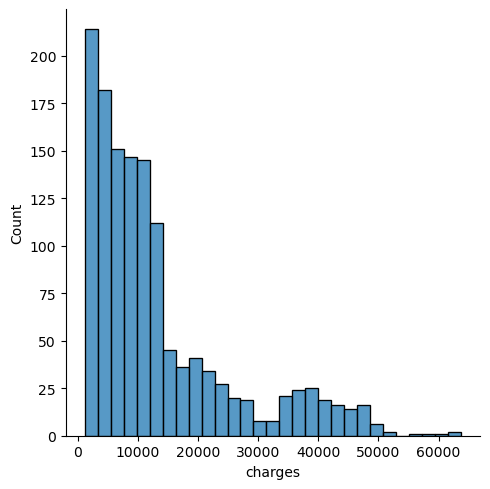

In [8]:
sns.displot(df['charges'])

<Axes: xlabel='smoker', ylabel='charges'>

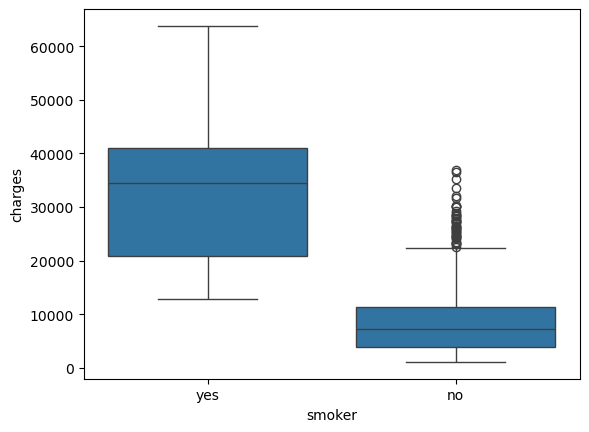

In [9]:
sns.boxplot(x = df['smoker'], y = df['charges'])

<Axes: xlabel='age', ylabel='charges'>

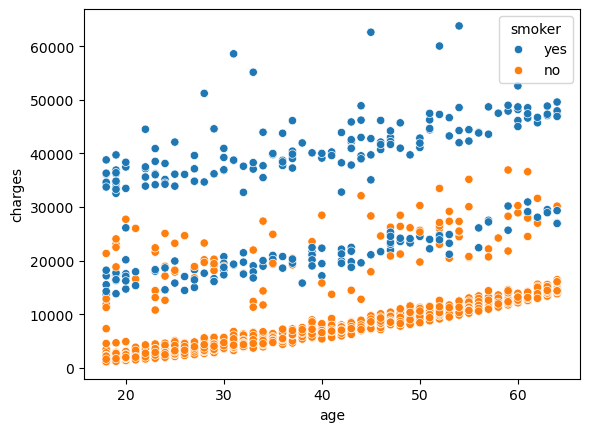

In [10]:
sns.scatterplot(data = df, x = 'age', y = 'charges',hue = 'smoker')

<Axes: xlabel='bmi', ylabel='charges'>

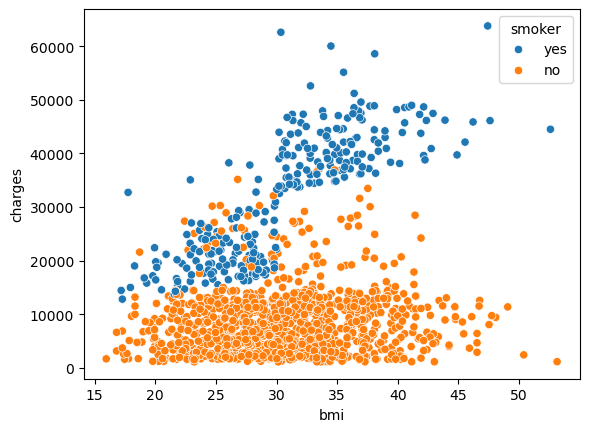

In [11]:
sns.scatterplot(data = df, x = 'bmi', y = 'charges',hue = 'smoker')

<Axes: xlabel='children', ylabel='charges'>

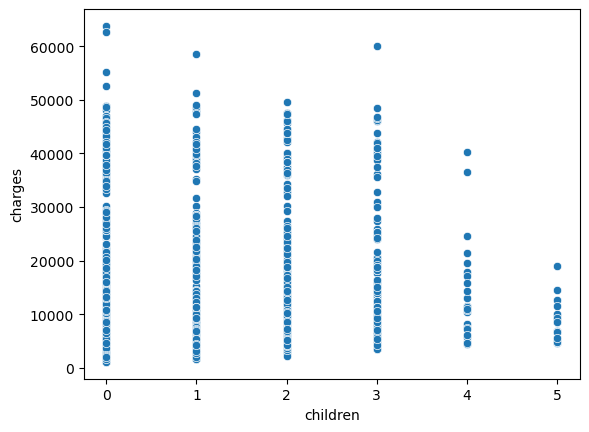

In [12]:
sns.scatterplot(data = df, x = 'children', y = 'charges')

In [13]:
df.value_counts('sex')

sex
male      675
female    662
Name: count, dtype: int64

In [14]:
df.value_counts('region')

region
southeast    364
southwest    325
northeast    324
northwest    324
Name: count, dtype: int64

In [15]:
df.value_counts('smoker')

smoker
no     1063
yes     274
Name: count, dtype: int64

In [16]:
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

In [17]:
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})

In [18]:
df = pd.get_dummies(df, columns=['region'], drop_first=True)

In [19]:
df['bmi_smoker_interaction'] = df['bmi'] * df['smoker']

In [20]:
df['age_squared'] = df['age'] ** 2

In [21]:
df.sample(5)

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_smoker_interaction,age_squared
339,46,1,27.72,1,0,8232.6388,False,True,False,0.0,2116
609,30,0,37.80,2,1,39241.4420,False,False,True,37.8,900
149,19,0,28.40,1,0,1842.5190,False,False,True,0.0,361
1336,21,1,25.80,0,0,2007.9450,False,False,True,0.0,441
386,58,1,39.05,0,0,11856.4115,False,True,False,0.0,3364


In [22]:
X = df.drop(columns=['charges'])
y = df['charges']

In [23]:
print(X.columns.to_list)

<bound method IndexOpsMixin.tolist of Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest',
       'region_southeast', 'region_southwest', 'bmi_smoker_interaction',
       'age_squared'],
      dtype='object')>


In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [25]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [26]:
ss = StandardScaler()
ss.fit_transform(X_train)
ss.transform(X_test)

array([[ 0.70051832, -0.97140947, -1.3267337 , ..., -0.57410974,
        -0.48788264,  0.59555916],
       [-0.72886531,  1.029432  , -0.8167329 , ...,  1.74182728,
        -0.48788264, -0.79378118],
       [ 0.84345668,  1.029432  ,  0.96620343, ..., -0.57410974,
        -0.48788264,  0.77367972],
       ...,
       [-1.22914958,  1.029432  ,  0.6678075 , ..., -0.57410974,
        -0.48788264, -1.11172637],
       [ 1.5581485 , -0.97140947,  0.95215155, ...,  1.74182728,
         2.4322725 ,  1.77115483],
       [ 0.55757996,  1.029432  , -1.02833777, ..., -0.57410974,
        -0.48788264,  0.42456343]], shape=(268, 10))

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,root_mean_squared_error,mean_absolute_error

In [28]:
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
y_pred = model.predict(X_test)

In [30]:
print("R2 Score",r2_score(y_test,y_pred))

R2 Score 0.8855591600954577


In [31]:
print("RMSE",root_mean_squared_error(y_test,y_pred))

RMSE 4585.760384758049


In [32]:
print("MAE",mean_absolute_error(y_test,y_pred))

MAE 2886.667447655288


In [33]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [34]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [35]:
rf_pred = rf_model.predict(X_test)

In [36]:
print("R2 Score:" ,r2_score(y_test, rf_preds))
print("MAE :" ,mean_absolute_error(y_test, rf_preds))

NameError: name 'rf_preds' is not defined

In [ ]:
import pickle
pickle.dump(rf_model, open("models/model1.pkl", "wb"))